#  추천 시스템 - ETF 추천 로직

1. LLM과 RAG를 결합한 추천 시스템의 아키텍처 이해
2. Text2SQL과 하이브리드 검색을 활용한 ETF 검색 시스템 구현
3. LangGraph를 활용한 다단계 워크플로우 설계 방법 습득
4. 구조화된 출력(Structured Output)을 통한 일관된 결과 생성 학습
5. Gradio를 이용한 AI 애플리케이션 배포 실습

---

## 환경 설정 및 준비

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

import warnings
warnings.filterwarnings('ignore')

`(3) SQLite DB`

In [3]:
from langchain_community.utilities import SQLDatabase

# ETF 데이터베이스 연결
db = SQLDatabase.from_uri(
    "sqlite:///etf_database.db",
    ignore_tables=['ETFsInfo']
    )

# 사용 가능한 테이블 목록 
print(db.dialect)
print(db.get_usable_table_names())
etfs = db.run("SELECT * FROM ETFs LIMIT 5;")

for etf in eval(etfs):
    print(etf)

sqlite
['ETFs']
('466400', '1Q 25-08 회사채(A+이상)액티브', '2023/09/19', '채권-회사채-단기', '하나자산운용', 4.52, 'KIS 2025-08만기형 크레딧 A+이상 지수(총수익)', 0.11, 111916276404.0, 0.03, '매우낮음', '실물(액티브)', 0.1, '배당소득세(보유기간과세)')
('491610', '1Q CD금리액티브(합성)', '2024/09/24', '기타', '하나자산운용', 0.0, 'KIS 하나 CD금리 총수익지수', 0.05, 316206006696.0, 0.02, '매우낮음', '합성(액티브)', 0.02, '배당소득세(보유기간과세)')
('451060', '1Q K200액티브', '2023/01/31', '주식-시장대표', '하나자산운용', -3.66, '코스피 200', 0.77, 99754348820.0, -0.01, '높음', '실물(액티브)', 0.18, '배당소득세(보유기간과세)')
('463290', '1Q 단기금융채액티브', '2023/08/03', '채권-혼합-단기', '하나자산운용', 4.01, 'MK 머니마켓 지수(총수익)', 0.05, 252717462257.0, 0.0, '매우낮음', '실물(액티브)', 0.08, '배당소득세(보유기간과세)')
('479080', '1Q 머니마켓액티브', '2024/04/02', '채권-혼합-단기', '하나자산운용', 0.0, 'KIS-하나 MMF 지수(총수익)', 0.06, 308255065986.0, -0.01, '매우낮음', '실물(액티브)', 0.05, '배당소득세(보유기간과세)')


`(4) SQL QA Chain`

-  DB 테이블에서 고유명사 추출

In [4]:
import ast
import re

def query_as_list(db, query):
    res = db.run(query)
    res = [el for sub in ast.literal_eval(res) for el in sub if el]
    # 1-2자리의 단독 숫자만 제거하고 연속된 공백을 단일 공백으로 치환
    res = [re.sub(r" +", " ", re.sub(r"\b\d{1,2}\b", "", string)).strip() for string in res]
    return list(set(res))


etfs = query_as_list(db, "SELECT DISTINCT 종목명 FROM ETFs")
fund_managers = query_as_list(db, "SELECT DISTINCT 운용사 FROM ETFs")
underlying_assets = query_as_list(db, "SELECT DISTINCT 기초지수 FROM ETFs")

print("ETFs:", len(etfs))
print("Fund Managers:", len(fund_managers))
print("Underlying Assets:", len(underlying_assets))

print(etfs[:5])
print(fund_managers[:5])
print(underlying_assets[:5])

ETFs: 925
Fund Managers: 26
Underlying Assets: 665
['RISE 수소경제테마', 'KODEX 차이나A50', 'RISE 글로벌테크놀로지(합성 H)', 'PLUS 글로벌방산', '파워 코스피100']
['케이비자산운용', '한국투자신탁운용', '엔에이치아문디자산운용', '아이비케이자산운용', '한화자산운용']
['Solactive AI인프라 지수', 'S&P500 Yen Hedged Index(PR)', 'Bloomberg Multi-Asset Weighted (KRW ETFs) 지수(시장가격)', 'WISE 삼성그룹 밸류 인덱스', 'KAP 미국채 20Y+ 지수(시장가격)']


- 고유명사를 벡터스토어에 저장

In [6]:
from langchain_openai import OpenAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore

# 임베딩 모델 생성
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
# 임베딩 벡터 저장소 생성
vector_store = InMemoryVectorStore(embeddings)

In [7]:
from langchain_core.documents import Document

# 1. 메타데이터(타입/분류)를 포함하는 Document 객체 생성
documents = []

# ETF 종목명 추가
for etf in etfs:
    documents.append(
        Document(
            page_content=etf,
            metadata={"type": "종목명"}
        )
    )

# 운용사 추가
for manager in fund_managers:
    documents.append(
        Document(
            page_content=manager,
            metadata={"type": "운용사"}
        )
    )

# 기초지수 추가
for asset in underlying_assets:
    documents.append(
        Document(
            page_content=asset,
            metadata={"type": "기초지수"}
        )
    )

# 2. Document 형식을 벡터 저장소에 저장
_ = vector_store.add_documents(documents)
vector_retriever = vector_store.as_retriever(search_kwargs={"k": 20})

In [10]:
from typing import Optional, Literal
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI

# 1. LLM이 출력할 구조 정의
class SearchQueryAnalyzer(BaseModel):
    query: str = Field(
        description="벡터 검색에 사용할 핵심 검색어 또는 고유명사 (예: '삼성', '다우존스', '미래에셋')"
    )
    filter_type: Optional[Literal["종목명", "운용사", "기초지수"]] = Field(
        default=None,
        description="사용자 질문에서 특정 타입의 대상을 검색하고자 하는 의도가 명확할 때만 지정합니다. (예: '삼성 운용사' -> '운용사', '코스피 지수 관련' -> '기초지수')"
    )

# 2. 구조화된 출력을 지원하는 LLM 선언
llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
structured_analyzer = llm.with_structured_output(SearchQueryAnalyzer)

# 3. 자연어 질문 분석 및 동적 필터 적용 검색 함수 정의
def search_vector_store(user_question: str):
    # LLM을 통해 질문 분석
    analysis: SearchQueryAnalyzer = structured_analyzer.invoke(user_question)
    print(f"질문 분석 결과: 쿼리='{analysis.query}', 필터='{analysis.filter_type}'")
    
    # 동적 필터 딕셔너리 생성
    # InMemoryVectorStore에 맞는 동적 필터 구현 예시
    if analysis.filter_type:
        # 각 Document의 metadata['type']과 추출된 filter_type을 동적으로 비교하는 람다 함수 전달
        search_filter = lambda doc: doc.metadata.get("type") == analysis.filter_type
    else:
        search_filter = None

        
    # 벡터 저장소 검색 실행
    results = vector_store.similarity_search(
        query=analysis.query,
        k=5,
        filter=search_filter
    )
    
    return results

# --- 테스트 예시 ---
# 1) 필터가 작동하는 경우 (운용사)
print("--- 테스트 1 ---")
results_1 = search_vector_store("삼성자산 운용사에서 나온 상품 알려줘")
for doc in results_1:
    print(f"[{doc.metadata['type']}] {doc.page_content}")

# 2) 필터가 작동하는 경우 (기초지수)
print("\n--- 테스트 2 ---")
results_2 = search_vector_store("코스피 지수 관련 ETF 검색해줘")
for doc in results_2:
    print(f"[{doc.metadata['type']}] {doc.page_content}")

# 3) 특정 분류가 애매하여 필터 없이 전체 검색하는 경우
print("\n--- 테스트 3 ---")
results_3 = search_vector_store("미래에셋 타이거는 뭐야?")
for doc in results_3:
    print(f"[{doc.metadata['type']}] {doc.page_content}")


--- 테스트 1 ---
질문 분석 결과: 쿼리='삼성자산 운용사에서 나온 상품', 필터='운용사'
[운용사] 삼성자산운용
[운용사] 삼성액티브자산운용
[운용사] 신한자산운용
[운용사] 우리자산운용
[운용사] 흥국자산운용

--- 테스트 2 ---
질문 분석 결과: 쿼리='코스피 지수 관련 ETF', 필터='기초지수'
[기초지수] 코스피
[기초지수] 코스피 우선주 지수
[기초지수] 코스피  ESG 지수
[기초지수] 코스피  금융
[기초지수] 코스피  Top  지수

--- 테스트 3 ---
질문 분석 결과: 쿼리='미래에셋 타이거는 뭐야?', 필터='운용사'
[운용사] 미래에셋자산운용
[운용사] 마이다스에셋
[운용사] 유리에셋
[운용사] 트러스톤자산운용
[운용사] 에셋플러스자산운용


- 고유명사를 키워드 검색으로 적용

In [13]:
### kiwipiepy 토크나이저 함수 정의

from kiwipiepy import Kiwi
import re

# Kiwi 토크나이저 초기화
kiwi = Kiwi()

def korean_tokenizer(text):
    """kiwipiepy를 사용한 한국어 토크나이징 함수"""
    # 기본 전처리
    text = re.sub(r'[^\w\s]', '', text)  # 특수문자 제거
    text = text.lower()  # 소문자 변환
    
    # Kiwi로 형태소 분석
    tokens = kiwi.tokenize(text)
    
    # 명사, 형용사, 동사, 외국어, 한자 등 필터링 (선별 추출)
    filtered_tokens = []
    for token in tokens:
        if token.tag in ['NNG', 'NNP', 'VA', 'VV', 'SL', 'SH']:  # 일반명사, 고유명사, 형용사, 동사, 외국어, 한자
            filtered_tokens.append(token.form)
    
    return filtered_tokens if filtered_tokens else [token.form for token in tokens]

# 테스트
print(korean_tokenizer("TIGER 미국배당다우존스타겟커버드콜2호"))


['tiger', '미국', '배당', '다우존스', '타겟', '커버', '드', '콜']


In [12]:
from langchain_community.retrievers import BM25Retriever
from langchain_core.documents import Document

# 고유명사를 Document 객체로 변환
# proper_noun_docs = [Document(page_content=name) for name in etfs + fund_managers + underlying_assets]
proper_noun_docs = documents

# BM25 검색기 생성 (Kiwi 토크나이저 적용)
bm25_retriever = BM25Retriever.from_documents(
    proper_noun_docs,
    preprocess_func=korean_tokenizer,
    k=20,
)
print(f"BM25 검색기 생성 완료: {len(proper_noun_docs)}개 문서 등록")

# 테스트
query = "다우존스 관련 ETF는 무엇인가요?"
results = bm25_retriever.invoke(query)
print(f"\nQuery: {query}")
print("-" * 40)
for result in results:
    print(f"Document: {result.page_content}")

BM25 검색기 생성 완료: 1616개 문서 등록

Query: 다우존스 관련 ETF는 무엇인가요?
----------------------------------------
Document: TIGER 미국다우존스30
Document: KRX 나스닥  ETF 선물지수
Document: KOSEF 미국ETF산업STOXX
Document: TIGER 미국나스닥100ETF선물
Document: 다우존스 인터넷 종합지수
Document: TIGER 미국배당다우존스
Document: SOL 미국배당다우존스
Document: KODEX 미국배당다우존스
Document: ACE 미국배당다우존스
Document: STOXX USA ETF Industry Index (KRW)
Document: KODEX 미국ETF산업Top10 Indxx
Document: KODEX 대만테크고배당다우존스
Document: SOL 미국배당다우존스TR
Document: SOL 미국배당다우존스(H)
Document: Indxx US ETF Industry Top10 Index(Price Return)
Document: PLUS 미국다우존스고배당주(합성 H)
Document: KRX 다우존스 미국배당국채 혼합지수
Document: KODEX 미국배당다우존스타겟커버드콜
Document: TIGER 미국배당다우존스타겟커버드콜2호
Document: TIGER 미국배당다우존스타겟커버드콜1호


In [15]:
### 하이브리드 앙상블 리트리버 생성 (RRF 직접 구현)
from typing import List, Dict
from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_core.retrievers import BaseRetriever

class RRFHybridRetriever(BaseRetriever):
    vector_retriever: BaseRetriever
    bm25_retriever: BaseRetriever
    k: int = 60
    top_n: int = 20

    def _get_relevant_documents(
        self, query: str, *, run_manager: CallbackManagerForRetrieverRun
    ) -> List[Document]:
        # 두 retriever로부터 문서 가져오기
        vector_docs = self.vector_retriever.invoke(query, config={"callbacks": run_manager.get_child()})
        bm25_docs = self.bm25_retriever.invoke(query, config={"callbacks": run_manager.get_child()})
        
        # RRF 점수 계산
        rrf_scores: Dict[str, float] = {}
        doc_map: Dict[str, Document] = {}
        
        for rank, doc in enumerate(vector_docs):
            doc_key = doc.page_content
            doc_map[doc_key] = doc
            rrf_scores[doc_key] = rrf_scores.get(doc_key, 0.0) + 1.0 / (self.k + rank + 1)
            
        for rank, doc in enumerate(bm25_docs):
            doc_key = doc.page_content
            doc_map[doc_key] = doc
            rrf_scores[doc_key] = rrf_scores.get(doc_key, 0.0) + 1.0 / (self.k + rank + 1)
            
        # 점수 기준 내림차순 정렬
        sorted_keys = sorted(rrf_scores.keys(), key=lambda x: rrf_scores[x], reverse=True)
        
        # 상위 top_n개 문서 반환
        return [doc_map[key] for key in sorted_keys[:self.top_n]]

ensemble_retriever = RRFHybridRetriever(
    vector_retriever=vector_retriever,
    bm25_retriever=bm25_retriever,
    k=60,
    top_n=20
)

# 테스트
query = "다우존스 관련 ETF는 무엇인가요?"
results = ensemble_retriever.invoke(query)
print(f"Query: {query}")
print("-" * 40)
for result in results:
    print(f"Document: {result.page_content}")

Query: 다우존스 관련 ETF는 무엇인가요?
----------------------------------------
Document: 다우존스 인터넷 종합지수
Document: KODEX 미국배당다우존스
Document: KODEX 대만테크고배당다우존스
Document: ACE 미국배당다우존스
Document: SOL 미국배당다우존스
Document: KRX 나스닥  ETF 선물지수
Document: TIGER 미국배당다우존스
Document: SOL 미국배당다우존스(H)
Document: TIGER 미국다우존스30
Document: SOL 미국배당다우존스TR
Document: KRX 다우존스 미국배당국채 혼합지수
Document: KODEX 미국ETF산업Top10 Indxx
Document: PLUS 미국다우존스고배당주(합성 H)
Document: KODEX 미국배당다우존스타겟커버드콜
Document: KOSEF 미국ETF산업STOXX
Document: TIGER 미국나스닥100ETF선물
Document: STOXX USA ETF Industry Index (KRW)
Document: KODEX iShares미국인플레이션국채액티브
Document: KODEX iShares미국투자등급회사채액티브
Document: Dow Jones U.S Select Dividend Index(시장가격지수)


- 검색 결과 변환하는 함수

In [16]:
from langchain_core.tools import tool

# 검색 도구 생성 - 하이브리드 검색기 사용
@tool("search_proper_nouns")
def entity_retriever_tool(query: str) -> str:
    """
    Use to look up values to filter on. Input is an approximate spelling 
    of the proper noun, output is valid proper nouns. Use the noun most 
    similar to the search.
    """
    docs = ensemble_retriever.invoke(query)
    return "\n\n".join([doc.page_content for doc in docs])

# 검색 도구 테스트
print(entity_retriever_tool.invoke("다우존스 관련 ETF는 무엇인가요?"))

다우존스 인터넷 종합지수

KODEX 미국배당다우존스

KODEX 대만테크고배당다우존스

ACE 미국배당다우존스

SOL 미국배당다우존스

KRX 나스닥  ETF 선물지수

TIGER 미국배당다우존스

SOL 미국배당다우존스(H)

TIGER 미국다우존스30

SOL 미국배당다우존스TR

KRX 다우존스 미국배당국채 혼합지수

KODEX 미국ETF산업Top10 Indxx

PLUS 미국다우존스고배당주(합성 H)

KODEX 미국배당다우존스타겟커버드콜

KOSEF 미국ETF산업STOXX

TIGER 미국나스닥100ETF선물

STOXX USA ETF Industry Index (KRW)

KODEX iShares미국인플레이션국채액티브

KODEX iShares미국투자등급회사채액티브

Dow Jones U.S Select Dividend Index(시장가격지수)


- 에이전트 정의

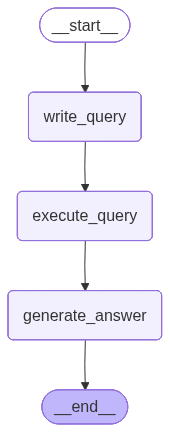

In [17]:
from typing import Annotated, TypedDict
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools import QuerySQLDatabaseTool
from langgraph.graph import START, StateGraph 
from IPython.display import Image, display

# 상태 정보를 저장하는 State 클래스
class State(TypedDict):
    question: str  # 입력 질문
    query: str     # 생성된 쿼리
    result: str    # 쿼리 결과
    answer: str    # 생성된 답변

# llm 모델 생성
llm = ChatOpenAI(model="gpt-4.1-mini")

# sql 쿼리 생성 프롬프트 
template = """
Given an input question, create a syntactically correct {dialect} query to run to help find the answer. Unless the user specifies in his question a specific number of examples they wish to obtain, always limit your query to at most {top_k} results. You can order the results by a relevant column to return the most interesting examples in the database.

Never query for all the columns from a specific table, only ask for a the few relevant columns given the question.

Pay attention to use only the column names that you can see in the schema description. Be careful to not query for columns that do not exist. Also, pay attention to which column is in which table.

Only use the following tables:
{table_info}

Entity names and their relationships to consider:
{entity_info}

## Matching Guidelines
- Use exact matches when comparing entity names
- Check for historical name variations if available
- Apply case-sensitive matching for official names
- Handle both Korean and English entity names when present

Question: {input}
"""
query_prompt_template = ChatPromptTemplate.from_template(template)

# SQL 쿼리 생성 함수
class QueryOutput(BaseModel):
    """Generated SQL query."""
    query: str = Field(description="Syntactically valid SQL query.")

def write_query(state: State):
    """Generate SQL query to fetch information."""
    prompt = query_prompt_template.invoke(
        {
            "dialect": db.dialect,
            "top_k": 10,
            "table_info": db.get_table_info(),
            "input": state["question"],
            "entity_info": entity_retriever_tool.invoke(state["question"]),
        }
    )
    structured_llm = llm.with_structured_output(QueryOutput)
    result = structured_llm.invoke(prompt)
    return {"query": result.query}

# SQL 쿼리 실행 함수
def execute_query(state: State):
    """Execute SQL query."""
    execute_query_tool = QuerySQLDatabaseTool(db=db)
    return {"result": execute_query_tool.invoke(state["query"])}

# 답변 생성 함수
def generate_answer(state: State):
    """Answer question using retrieved information as context."""
    prompt = (
        "Given the following user question, corresponding SQL query, "
        "and SQL result, answer the user question.\n\n"
        f'Question: {state["question"]}\n'
        f'SQL Query: {state["query"]}\n'
        f'SQL Result: {state["result"]}'
    )
    response = llm.invoke(prompt)
    return {"answer": response.content}


# 상태 그래프 생성
graph_builder = StateGraph(State)

graph_builder.add_node("write_query", write_query)
graph_builder.add_node("execute_query", execute_query)
graph_builder.add_node("generate_answer", generate_answer)

graph_builder.add_edge(START, "write_query")
graph_builder.add_edge("write_query", "execute_query")
graph_builder.add_edge("execute_query", "generate_answer")  
graph = graph_builder.compile()

# 상태 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
# 고유명사를 사용하는 쿼리 테스트 - 운용사
for step in graph.stream(
    {"question": "케이비에서 운용하는 헬스케어 ETF는 무엇인가요?"}, stream_mode="updates"
):
    print(step)

{'write_query': {'query': "SELECT 종목코드, 종목명, 수익률_최근1년, 순자산총액 FROM ETFs WHERE 운용사 = '케이비자산운용' AND 분류체계 LIKE '%헬스케어%' LIMIT 10;"}}
{'execute_query': {'result': "[('253280', 'RISE 헬스케어', 17.51, 6864932325.0)]"}}
{'generate_answer': {'answer': "케이비자산운용에서 운용하는 헬스케어 ETF는 'RISE 헬스케어'입니다."}}


In [20]:
# 고유명사를 사용하는 쿼리 테스트 - 기초지수, 펀드명
for step in graph.stream(
    {"question": "다우존스를 기초지수로 하는 ETF를 찾아주세요."}, stream_mode="updates"
):
    print(step)

{'write_query': {'query': "SELECT 종목코드, 종목명, 운용사, 수익률_최근1년 FROM ETFs WHERE 기초지수 LIKE '%다우존스%' ORDER BY 수익률_최근1년 DESC LIMIT 10;"}}
{'execute_query': {'result': "[('280320', 'ACE 미국IT인터넷S&P(합성 H)', '한국투자신탁운용', 39.74), ('490490', 'SOL 미국배당미국채혼합50', '신한자산운용', 0.0)]"}}
{'generate_answer': {'answer': '다우존스를 기초지수로 하는 ETF를 검색한 결과, 해당하는 ETF가 없습니다. 제공된 결과는 다우존스가 기초지수가 아닌 다른 ETF들로 보입니다.\n\n만약 다우존스를 기초지수로 하는 ETF가 있다면, 리스트에서 확인할 수 있지만 현재 데이터에서는 찾을 수 없습니다. 추가적으로 확인할 필요가 있을 수 있습니다.'}}


## **LLM과 RAG를 결합한 추천 시스템** 

- **전통적인 추천** 시스템의 주요 문제점들:
    - **데이터 희소성** 문제로 인해 대부분의 사용자-아이템 상호작용 정보가 부족함
    - 신규 사용자나 아이템에 대한 **콜드 스타트** 현상으로 초기 추천이 어려움
    - **명시적 피드백**(평점, 리뷰)의 수집이 제한적이며 신뢰성에 한계가 있음 
    - **틈새 아이템**과 신규 콘텐츠는 충분한 상호작용 데이터 확보가 어려워 추천이 제한됨 

- **RAG 기반 추천** 시스템의 가능성:

    - **벡터 데이터베이스**와 **LLM**을 결합하여 효율적인 검색과 자연어 처리를 구현
    - **LangChain** 기반 파이프라인으로 상품 데이터의 벡터화부터 추천까지 일관된 프로세스를 구축함
    - **RAG 시스템**을 통해 컨텍스트를 고려한 개인화된 추천이 가능함
    - 전통적 추천 시스템의 한계를 **자연어 기반 추천**으로 보완하여 더 풍부한 설명을 제공 가능

### 1) **전체 시스템 개요**

- **상태 관리 시스템**이 사용자 프로필부터 추천 결과까지 체계적으로 데이터를 관리

- 각 단계별 추천 정확도를 높일 수 있도록 세분화된 **프로세스 체인**으로 역할을 구분

- **구조화된 프롬프트**를 통해 일관된 형식의 결과물을 생성

- **출력 데이터**가 JSON 형식으로 표준화되어 후속 처리에 활용 

```mermaid
flowchart LR
    Q[사용자 질문] --> P[프로필 분석]
    P -->|투자 성향 & 목표 추출| S[SQL 쿼리 생성]
    S -->|데이터베이스 조회| E[후보 ETF 검색]
    E -->|필터링 조건 적용| R[랭킹 및 필터링]
    R -->|상위 후보 선정| D[설명 생성]
    
    style Q fill:#e1f5fe,stroke:#01579b
    style P fill:#e8f5e9,stroke:#1b5e20
    style S fill:#fff3e0,stroke:#e65100
    style E fill:#f3e5f5,stroke:#4a148c
    style R fill:#fbe9e7,stroke:#bf360c
    style D fill:#e8eaf6,stroke:#1a237e

    subgraph 데이터 처리
    S
    E
    R
    end

    subgraph 출력 생성
    D
    end
```

### 2) **상태(State) 관리**

- **State** 클래스는 **TypedDict**를 상속받아 ETF 추천 시스템의 상태를 관리함
- 사용자와의 상호작용 정보를 **question**과 **user_profile**에 저장
- ETF 분석 결과는 **candidates**와 **rankings** 리스트에 보관
- 최종 출력 관련 데이터는 **explanation**과 **final_answer**에 기록

In [21]:
from typing import TypedDict

# 상태 정보를 저장하는 State 클래스
class State(TypedDict):
    question: str          # 사용자 입력 질문
    user_profile: dict     # 사용자 프로필 정보
    query: str             # 생성된 SQL 쿼리
    candidates: list       # 후보 ETF 목록
    rankings: list         # 순위가 매겨진 ETF 목록
    explanation: str       # 추천 이유 설명
    final_answer: str      # 최종 추천 답변

### 3) **프로세스 체인**

- 시스템은 **사용자 입력**으로 시작하여 **프로필 분석**을 통해 맞춤형 추천을 준비함
- **SQL 쿼리**와 **ETF 검색** 과정을 통해 데이터베이스에서 적절한 상품을 찾음
- **랭킹 시스템**을 통해 최적의 ETF를 선별하고 **맞춤형 설명**을 생성함

`(1) 사용자 프로필 분석`

- 시스템은 사용자의 **투자 성향**과 **위험 선호도**를 먼저 파악함
- **투자 목표**, **투자 기간**, **투자 가능 금액**을 종합적으로 분석
- 사용자의 **과거 투자 이력**과 **현재 포트폴리오** 구성을 검토
- 프로필 분석은 **개인화된 ETF 추천**을 위한 핵심 기초 데이터를 제공함


In [22]:
from enum import Enum
from typing import List
from pydantic import BaseModel, Field

class RiskTolerance(Enum):
    CONSERVATIVE = "conservative"
    MODERATE = "moderate" 
    AGGRESSIVE = "aggressive"

class InvestmentHorizon(Enum):
    SHORT = "short"
    MEDIUM = "medium"
    LONG = "long"

class InvestmentProfile(BaseModel):
    risk_tolerance: RiskTolerance = Field(
        description="투자자의 위험 성향 (conservative/moderate/aggressive)"
    )
    investment_horizon: InvestmentHorizon = Field(
        description="투자 기간 (short/medium/long)"
    )
    investment_goal: str = Field(
        description="투자의 주요 목적 설명"
    )
    preferred_sectors: List[str] = Field(
        description="선호하는 투자 섹터 목록"
    )
    excluded_sectors: List[str] = Field(
        description="투자를 원하지 않는 섹터 목록"
    )
    monthly_investment: int = Field(
        description="월 투자 가능 금액 (원)"
    )

In [23]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# 사용자 프로필 분석 프롬프트
PROFILE_TEMPLATE= """
사용자의 질문을 분석하여 투자 프로필을 생성해주세요.

사용자 질문: {question}
"""

profile_prompt = ChatPromptTemplate.from_template(PROFILE_TEMPLATE)

# 사용자 프로필 분석 모델 생성
llm = ChatOpenAI(model="gpt-4.1-mini")
profile_llm = llm.with_structured_output(InvestmentProfile)

# 사용자 프로필 분석 함수
def analyze_profile(state: State) -> dict:
    """사용자 질문을 분석하여 투자 프로필 생성"""
    prompt = profile_prompt.invoke({"question": state["question"]})
    response = profile_llm.invoke(prompt)
    return {"user_profile": dict(response)}


# 예시 질문 
question = """
저는 30대 초반의 직장인입니다. 
월 100만원 정도를 3년 이상 장기 투자하고 싶고,
기술 섹터와 헬스케어에 관심이 있습니다.
중위험 중수익을 추구하며, ESG 요소도 고려하고 싶습니다.
적합한 ETF를 추천해주세요.
"""

# 사용자 프로필 분석
result_profile = analyze_profile({"question": question})

# 결과 출력
result_profile

{'user_profile': {'risk_tolerance': <RiskTolerance.MODERATE: 'moderate'>,
  'investment_horizon': <InvestmentHorizon.LONG: 'long'>,
  'investment_goal': '중위험 중수익을 추구하며 ESG 요소를 고려한 장기 투자',
  'preferred_sectors': ['기술', '헬스케어'],
  'excluded_sectors': [],
  'monthly_investment': 1000000}}

`(2) ETF 검색 쿼리 프롬프트 생성`

- **사용자 프로필** {user_profile}과 **입력 질문** {input}에 따라 최적화된 쿼리 생성

In [ ]:
from typing import TypedDict, Annotated
from langchain_core.prompts import ChatPromptTemplate

# SQL Query Generation Template
QUERY_TEMPLATE = """
Given an input question and investment profile, create a syntactically correct {dialect} query to run. Unless specified, limit your query to at most {top_k} results. Order the results by most relevant columns based on the investment profile.

Never query for all columns from a specific table, only ask for relevant columns given the question and investment criteria.

Pay attention to use only the column names you can see in the schema description. Be careful to not query for columns that do not exist. Also, pay attention to which column is in which table.

Available tables:
{table_info}

Entity relationships:
{entity_info}

## Matching Guidelines
- Use exact matches when comparing entity names
- Check for historical name variations if available
- Apply case-sensitive matching for official names
- Handle both Korean and English entity names when present

Investment Profile:
{user_profile}

Question: {input}

## Constraints
1. Use only existing columns
2. Query only necessary columns (no SELECT *)
3. Follow correct table relationships
4. Consider performance and indexing
"""

# SQL Query Generation Prompt Template
query_prompt_template = ChatPromptTemplate.from_template(QUERY_TEMPLATE)

# SQL Query Output
from pydantic import BaseModel, Field
class QueryOutput(BaseModel):
    """Generated SQL query."""
    query: str = Field(description="Syntactically valid SQL query.")
    explanation: str = Field(description="Query explanation and selection criteria (in 한국어)")


def write_query(state: State):
    """Generate SQL query to fetch information."""
    prompt = query_prompt_template.invoke(
        {
            "dialect": db.dialect,
            "top_k": 10,
            "table_info": db.get_table_info(),
            "input": state["question"],
            "entity_info": entity_retriever_tool.invoke(state["question"]),
            "user_profile": state["user_profile"],
        }
    )
    structured_llm = ChatOpenAI(model="gpt-4.1").with_structured_output(QueryOutput)
    result = structured_llm.invoke(prompt)
    return {"query": result.query, "explanation": result.explanation}

# 테스트
result_query = write_query({ 
    "question": question,
    "user_profile": result_profile["user_profile"]
})

# 결과 출력
result_query


{'query': "SELECT 종목코드, 종목명, 수익률_최근1년, 분류체계, 운용사, 기초지수, 변동성, 총보수\nFROM ETFs\nWHERE (\n    분류체계 LIKE '%기술%' OR 분류체계 LIKE '%테크%' OR 분류체계 LIKE '%헬스케어%' OR 분류체계 LIKE '%바이오%'\n    OR 기초지수 LIKE '%ESG%' OR 분류체계 LIKE '%ESG%'\n)\nAND 변동성 IN ('보통', '중간', '중간이상', '중간이하', '중간', '보통이상')\nORDER BY 수익률_최근1년 DESC, 변동성 ASC, 총보수 ASC\nLIMIT 10;",
 'explanation': "중위험(변동성이 '보통' 혹은 '중간' 등)과 중수익(수익률_최근1년 높은순)을 우선시하였고, 기술・헬스케어 혹은 ESG 관련 ETF만 추천 대상으로 삼았습니다. 투자성향에 맞게 총보수(낮을수록 좋음) 기준도 후순위로 두었습니다. 10개만 추천 리스트에 포함합니다."}

`(3) ETF 검색 쿼리 실행`

In [25]:
from langchain_community.tools import QuerySQLDatabaseTool

def execute_query(state: State) -> dict:
    """SQL 쿼리 실행하여 후보 ETF 검색"""
    try:
        execute_query_tool = QuerySQLDatabaseTool(db=db)
        results = execute_query_tool.invoke(state["query"])
        if not results or results == "[]":
            return {"candidates": "검색 결과가 없습니다."}
        return {"candidates": results}
    except Exception as e:
        return {"candidates": f"쿼리 실행 중 오류 발생: {str(e)}"}

# 테스트
result_candidates = execute_query({
    "query": result_query["query"]
})

# 결과 출력
result_candidates

{'candidates': "[('203780', 'TIGER 미국나스닥바이오', 16.47, '주식-업종섹터-헬스케어', '미래에셋자산운용', 'NASDAQ Biotechnology 지수(시장가격지수)', '보통', 0.3), ('285690', 'FOCUS ESG리더스', 4.28, '주식-전략-전략테마', '브이아이자산운용', 'KRX ESG Leaders 150', '보통', 0.1), ('289250', 'TIGER MSCI KOREA ESG유니버설', -4.12, '주식-전략-전략테마', '미래에셋자산운용', 'MSCI Korea ESG Universal Index', '보통', 0.4), ('395750', 'PLUS ESG가치주액티브', -4.69, '주식-전략-전략테마', '한화자산운용', 'FnGuide 한화 ESG 가치 지수', '보통', 0.105)]"}

In [26]:
for candidate in eval(result_candidates["candidates"]):
    print(candidate)

('203780', 'TIGER 미국나스닥바이오', 16.47, '주식-업종섹터-헬스케어', '미래에셋자산운용', 'NASDAQ Biotechnology 지수(시장가격지수)', '보통', 0.3)
('285690', 'FOCUS ESG리더스', 4.28, '주식-전략-전략테마', '브이아이자산운용', 'KRX ESG Leaders 150', '보통', 0.1)
('289250', 'TIGER MSCI KOREA ESG유니버설', -4.12, '주식-전략-전략테마', '미래에셋자산운용', 'MSCI Korea ESG Universal Index', '보통', 0.4)
('395750', 'PLUS ESG가치주액티브', -4.69, '주식-전략-전략테마', '한화자산운용', 'FnGuide 한화 ESG 가치 지수', '보통', 0.105)


`(4) 후보 ETF 랭킹 및 필터링`

- **랭킹 시스템**은 **수익률**, **순자산총액**, **총보수**, **변동성** 등 5가지 핵심 지표를 평가함
- 순위 결정에는 **사용자 프로필** {user_profile}과 **후보 ETF** {candidates} 정보가 활용됨
- 각 ETF는 **점수화**되어 상위 3개가 출력됨

In [ ]:
from typing import TypedDict, Annotated
from langchain_core.prompts import ChatPromptTemplate

RANKING_TEMPLATE = """
Rank the following ETF candidates based on the user's investment profile and return the top 3(three) ETFs.
Consider these factors when ranking:

1. 수익률
2. 변동성
3. 순자산총액
4. 총보수
5. User Profile matching score

User Profile:
{user_profile}

Candidate ETFs:
{candidates}

Table Info:
(table_info)
"""

# ETF Ranking Prompt Template
ranking_prompt = ChatPromptTemplate.from_template(RANKING_TEMPLATE)


# ETF Ranking Output
class ETFRanking(TypedDict):
    """Individual ETF ranking result"""
    rank: Annotated[int, ..., "Ranking position (1-5)"]
    etf_code: Annotated[str, ..., "ETF 종목코드 (6-digit)"]
    etf_name: Annotated[str, ..., "ETF 종목명"]
    score: Annotated[float, ..., "Composite score (0-100)"]
    ranking_reason: Annotated[str, ..., "Explanation for the ranking (in 한국어)"]

class ETFRankingResult(TypedDict):
    """Ranked ETFs"""
    rankings: List[ETFRanking]

# ETF Ranking Function
def rank_etfs(state: State) -> dict:
    """Rank ETF candidates based on user's investment profile"""
    prompt = ranking_prompt.invoke(
        {
            "user_profile": state["user_profile"],
            "candidates": state["candidates"],
            "table_info": db.get_table_info(),
        }
    )
    structured_llm = ChatOpenAI(model="gpt-4.1").with_structured_output(ETFRankingResult)
    results = structured_llm.invoke(prompt)

    return {"rankings": results}

# 테스트
result_rankings = rank_etfs({
    "user_profile": result_profile["user_profile"],
    "candidates": result_candidates["candidates"]
})  # type: ignore

# 결과 출력
result_rankings

{'rankings': {'rankings': [{'rank': 1,
    'etf_code': '203780',
    'etf_name': 'TIGER 미국나스닥바이오',
    'score': 90,
    'ranking_reason': '수익률(16.47%)이 높고, 헬스케어 섹터로 사용자의 선호 섹터와 잘 부합하며, 장기 투자에 적합한 성장성을 기대할 수 있습니다. 변동성이 있지만, 중위험 중수익을 지향하는 사용자와 잘 맞습니다.'},
   {'rank': 2,
    'etf_code': '285690',
    'etf_name': 'FOCUS ESG리더스',
    'score': 80,
    'ranking_reason': 'ESG 요소를 반영한 ETF로 사용자 투자 목표에 부합하며, 수익률(4.28%)도 안정적으로 보입니다. 총보수(0.1%)가 매우 낮아 장기투자에 적합합니다.'},
   {'rank': 3,
    'etf_code': '289250',
    'etf_name': 'TIGER MSCI KOREA ESG유니버설',
    'score': 65,
    'ranking_reason': 'ESG 테마에 부합하고 총보수는 다소 높으나, 안정적인 ESG 지수 추종으로 장기 투자에 적합합니다. 최근 수익률은 다소 부진하나, 중위험 중수익과 가치 투자에 맞는 상품입니다.'}]}}

`(5) 추천 설명 생성`

- ETF 설명은 **주요 특징{rankings}** 과 **사용자 적합성{user_profile}** 을 중심으로 구성
- **포트폴리오 구성안**을 제시하여 **실용적이고 이해하기 쉬운** 실질적인 투자 가이드를 제공
- **리스크 요소**와 **주의사항**을 명확히 설명하여 투자자 보호를 강화

In [28]:
from typing import List
from pydantic import BaseModel, Field
from decimal import Decimal
from langchain_core.prompts import ChatPromptTemplate

EXPLANATION_TEMPLATE = """
Please provide a comprehensive explanation for the recommended ETFs based on the user's investment profile.


[RECOMMENDATION EXPLANATION (Examples)]
1. ETF Characteristics
   - Investment strategy and approach
   - Historical performance overview
   - Fee structure and efficiency
   - Underlying assets and diversification

2. Profile Fit Analysis
   - Alignment with risk tolerance
   - Match with investment horizon
   - Sector preference compatibility
   - Investment goal contribution

3. Portfolio Construction
   - Recommended allocation percentages
   - Diversification benefits
   - Rebalancing considerations
   - Implementation strategy

4. Risk Considerations
   - Market risk factors
   - Specific ETF risks
   - Economic scenario impacts
   - Monitoring requirements

--------------------------------------------

[User Profile]
{user_profile}

[Selected ETFs]
{rankings}
"""

# 추천 설명 프롬프트
explanation_prompt = ChatPromptTemplate.from_template(EXPLANATION_TEMPLATE)


# 추천 설명 출력 스키마
class ETFRecommendation(BaseModel):
   """Individual ETF recommendation details"""
   etf_code: str = Field(..., description="ETF 종목코드 (6-digit)")
   etf_name: str = Field(..., description="ETF 종목명")
   allocation: Decimal = Field(..., description="Recommended allocation % (0-100)")
   description: str = Field(..., description="ETF description and investment strategy (in 한국어)")
   key_points: List[str] = Field(..., description="Key investment points (in 한국어)")
   risks: List[str] = Field(..., description="Risk factors to consider (in 한국어)")

class RecommendationExplanation(BaseModel):
   """ETF recommendation explanation with markdown formatting"""
   overview: str = Field(..., description="Overall strategy explanation (in 한국어)")
   recommendations: List[ETFRecommendation] = Field(..., description="ETF details")
   considerations: List[str] = Field(..., description="Important considerations (in 한국어)")
   
   # 마크다운 포맷으로 출력
   def to_markdown(self) -> str:
      """Convert explanation to markdown format"""
      markdown = [
            "# ETF 포트폴리오 추천",
            "",
            "## 투자 전략 개요",
            self.overview,
            "",
            "## 추천 ETF 포트폴리오",
            ""
      ]
      
      # 포트폴리오 구성 비율
      markdown.extend([
            "| ETF | 종목코드 | 추천비중 |",
            "|-----|----------|----------|"
      ])
      
      for rec in self.recommendations:
         markdown.append(
            f"| {rec.etf_name} | {rec.etf_code} | {rec.allocation}% |"
            )
      
      # ETF 상세 설명
      markdown.append("\n## ETF 상세 설명\n")
      
      for rec in self.recommendations:
         markdown.extend([
               f"### {rec.etf_name} ({rec.etf_code})",
               rec.description,
               "",
               "**주요 투자 포인트:**",
               "".join([f"\n* {point}" for point in rec.key_points]),
               "",
               "**투자 위험:**",
            "".join([f"\n* {risk}" for risk in rec.risks]),
         ""
         ])
      
      # 투자 리스크 고려사항
      markdown.extend([
            "## 투자 시 고려사항",
            "".join([f"\n* {item}" for item in self.considerations]),
            ""
      ])
      
      return "\n".join(markdown)
   

# 추천 설명 생성 함수
def generate_explanation(state: dict) -> dict:
   """Generate structured ETF recommendation explanation"""
   # 프롬프트 생성
   prompt = explanation_prompt.invoke({
      "rankings": state["rankings"],
      "user_profile": state["user_profile"]
   })
   
   # 구조화된 출력 생성
   structured_llm = ChatOpenAI(model="gpt-4.1-mini").with_structured_output(RecommendationExplanation)
   response = structured_llm.invoke(prompt)

   return {"final_answer": {
      "explanation": response.model_dump(), 
      "markdown": response.to_markdown()
   }}
   

# 테스트
result_explanation = generate_explanation({
   "rankings": result_rankings["rankings"],
   "user_profile": result_profile["user_profile"]
})

In [29]:
# 결과 출력
result_explanation["final_answer"]["explanation"]

{'overview': '본 투자 포트폴리오는 사용자의 투자 성향인 중위험·중수익, 장기 투자 목표, 그리고 ESG 요소와 선호 섹터(기술, 헬스케어)를 고루 반영하였습니다. 삼종 ETF를 통해 헬스케어 성장성, ESG 리더십, 그리고 한국 시장 ESG 가치 투자를 적절히 조합하여 안정성과 성장성을 균형 있게 추구합니다. 또한, 낮은 총보수와 적절한 분산투자를 통해 장기적으로 꾸준한 수익 창출과 위험 완화를 도모합니다.',
 'recommendations': [{'etf_code': '203780',
   'etf_name': 'TIGER 미국나스닥바이오',
   'allocation': Decimal('50'),
   'description': '미국 나스닥 바이오 분야에 집중 투자하는 ETF로, 헬스케어 섹터의 혁신적 성장주에 노출되어 있습니다. 장기 투자 시 높은 성장 잠재력을 기대할 수 있으나 변동성도 상대적으로 큽니다.',
   'key_points': ['헬스케어 섹터에 특화된 성장형 ETF',
    '최근 수익률 약 16.47%로 우수한 성장세',
    '중위험을 선호하는 투자자에게 적합',
    '성장 잠재력 높은 미국 바이오 산업 집중투자'],
   'risks': ['바이오 섹터 특유의 변동성 및 규제 위험',
    '미국 시장 및 기술주에 대한 민감도',
    '단기 시장 조정 시 가격 변동 가능성']},
  {'etf_code': '285690',
   'etf_name': 'FOCUS ESG리더스',
   'allocation': Decimal('30'),
   'description': '국내외 ESG 우수기업에 투자하는 ETF로, ESG 요소를 고려한 투자 전략이 특징입니다. 낮은 총보수(0.1%)와 안정적 수익률(4.28%)을 보여 장기 투자에 적합합니다.',
   'key_points': ['ESG 요소를 반영한 책임 투자 ETF',
    '낮은 운용보수로 비용 효율적',
    '안정적 수익률과 지속가능한 성장 추구'

In [30]:
# 마크다운 출력
from IPython.display import Markdown
Markdown(result_explanation["final_answer"]["markdown"])

# ETF 포트폴리오 추천

## 투자 전략 개요
본 투자 포트폴리오는 사용자의 투자 성향인 중위험·중수익, 장기 투자 목표, 그리고 ESG 요소와 선호 섹터(기술, 헬스케어)를 고루 반영하였습니다. 삼종 ETF를 통해 헬스케어 성장성, ESG 리더십, 그리고 한국 시장 ESG 가치 투자를 적절히 조합하여 안정성과 성장성을 균형 있게 추구합니다. 또한, 낮은 총보수와 적절한 분산투자를 통해 장기적으로 꾸준한 수익 창출과 위험 완화를 도모합니다.

## 추천 ETF 포트폴리오

| ETF | 종목코드 | 추천비중 |
|-----|----------|----------|
| TIGER 미국나스닥바이오 | 203780 | 50% |
| FOCUS ESG리더스 | 285690 | 30% |
| TIGER MSCI KOREA ESG유니버설 | 289250 | 20% |

## ETF 상세 설명

### TIGER 미국나스닥바이오 (203780)
미국 나스닥 바이오 분야에 집중 투자하는 ETF로, 헬스케어 섹터의 혁신적 성장주에 노출되어 있습니다. 장기 투자 시 높은 성장 잠재력을 기대할 수 있으나 변동성도 상대적으로 큽니다.

**주요 투자 포인트:**

* 헬스케어 섹터에 특화된 성장형 ETF
* 최근 수익률 약 16.47%로 우수한 성장세
* 중위험을 선호하는 투자자에게 적합
* 성장 잠재력 높은 미국 바이오 산업 집중투자

**투자 위험:**

* 바이오 섹터 특유의 변동성 및 규제 위험
* 미국 시장 및 기술주에 대한 민감도
* 단기 시장 조정 시 가격 변동 가능성

### FOCUS ESG리더스 (285690)
국내외 ESG 우수기업에 투자하는 ETF로, ESG 요소를 고려한 투자 전략이 특징입니다. 낮은 총보수(0.1%)와 안정적 수익률(4.28%)을 보여 장기 투자에 적합합니다.

**주요 투자 포인트:**

* ESG 요소를 반영한 책임 투자 ETF
* 낮은 운용보수로 비용 효율적
* 안정적 수익률과 지속가능한 성장 추구
* 사용자 투자목표인 ESG 고려 투자에 부합

**투자 위험:**

* ESG 평가 기준 변화에 따른 구성 종목 변동
* 시장 전반 하락 시에도 가치 하락 가능성
* ESG 테마 투자로 인한 특정 섹터 집중 위험

### TIGER MSCI KOREA ESG유니버설 (289250)
한국 시장 내 ESG 우수기업에 초점을 맞춘 ETF로, ESG 테마와 가치투자를 접목하여 중위험 중수익 전략에 적합합니다. 총보수는 다소 높으나 안정적인 지수 추종을 제공합니다.

**주요 투자 포인트:**

* 한국 ESG 우수기업에 분산 투자
* 가치 투자 요소를 고려한 구성
* 장기적 안정성과 성장 기대 가능
* 중위험·중수익 투자자에게 부합

**투자 위험:**

* 국내 시장 및 ESG 테마 관련 리스크
* 수익률 변동성 및 운용 보수 부담
* 경제 상황 변화에 따른 기업 실적 영향

## 투자 시 고려사항

* 포트폴리오 구성 시 각 ETF의 변동성과 상관관계를 고려하여 분산투자 효과를 극대화해야 합니다.
* 장기 투자 목표에 맞추어 단기 변동성에 일희일비하지 않고 꾸준한 투자를 지속하는 것이 중요합니다.
* ESG 관련 정책이나 시장 변화에 따른 영향 가능성을 주기적으로 모니터링해야 합니다.
* 정기적인 리밸런싱을 통해 각 ETF의 목표 비율을 유지하고 투자 위험을 관리해야 합니다.


`(6) 상태 그래프 생성`

- 전체 프로세스 체인을 연결하여 상태 그래프를 생성

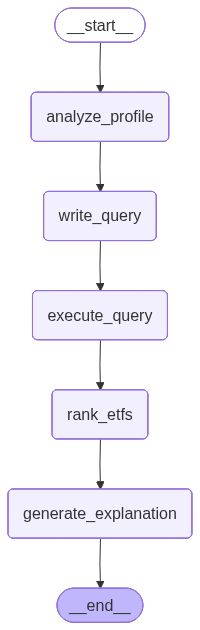

In [31]:
from langgraph.graph import StateGraph, START, END

# 상태 그래프 생성
graph_builder = StateGraph(State)

graph_builder.add_node("analyze_profile", analyze_profile)
graph_builder.add_node("write_query", write_query)
graph_builder.add_node("execute_query", execute_query)
graph_builder.add_node("rank_etfs", rank_etfs)
graph_builder.add_node("generate_explanation", generate_explanation)

graph_builder.add_edge(START, "analyze_profile")
graph_builder.add_edge("analyze_profile", "write_query")
graph_builder.add_edge("write_query", "execute_query")
graph_builder.add_edge("execute_query", "rank_etfs")
graph_builder.add_edge("rank_etfs", "generate_explanation")
graph_builder.add_edge("generate_explanation", END)

graph = graph_builder.compile()


# 상태 그래프 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
# 사용자 질문 예시

test_questions = [
    """
    40대 중반의 직장인입니다. 
    월 200만원 정도를 1년 이상 장기 투자하고 싶고,
    환율과 금리에 관심이 있습니다.
    저위험 안정적인 수익을 추구하며, ESG 요소도 고려하고 싶습니다.
    적합한 ETF를 추천해주세요.
    """,
    """
    20대 후반의 대학생입니다. 
    월 50만원 정도를 1년 이상 장기 투자하고 싶고,
    환율과 금리에 관심이 있습니다.
    고위험 고수익을 추구하며, ESG 요소도 고려하고 싶습니다.
    적합한 ETF를 추천해주세요.
    """,
    """
    32살 맞벌이 부부입니다. 
    둘이 합쳐서 월 200만원을 노후자금으로 굴리고 싶어요. 
    제약/바이오와 클라우드 컴퓨팅 쪽을 보고 있습니다. 
    안정성과 수익성의 균형을 맞추고 싶고, 
    지속가능한 기업들 위주로 투자하고 싶습니다.
    적합한 ETF를 추천해주세요.
    """
]


# 상태 그래프 실행
etf_recommendations = []
for question in test_questions:
    etf_recommendation = graph.invoke(
        {"question": question}
    )
    etf_recommendations.append(etf_recommendation)

In [33]:
# 결과 출력
Markdown(etf_recommendations[0]["final_answer"]["markdown"])

# ETF 포트폴리오 추천

## 투자 전략 개요
본 포트폴리오는 보수적인 투자성향과 장기 투자 목표를 고려하여 안정적인 수익 추구와 ESG 요소 반영을 목표로 설계되었습니다. 선호하시는 환율, 금리, ESG 관련 자산을 최대한 포함하였으며, 각 ETF는 낮은 변동성과 우수한 수익률을 바탕으로 자산의 안정성과 성장성을 균형 있게 제공합니다.

## 추천 ETF 포트폴리오

| ETF | 종목코드 | 추천비중 |
|-----|----------|----------|
| KODEX TRF7030 | KODEX TRF7030 | 50% |
| ACE 미국나스닥100채권혼합액티브 | ACE 미국나스닥100채권혼합액티브 | 30% |
| ACE 미국S&P500채권혼합액티브 | ACE 미국S&P500채권혼합액티브 | 20% |

## ETF 상세 설명

### KODEX TRF7030 (KODEX TRF7030)
KODEX TRF7030은 주식 70%와 채권 30%로 구성된 혼합형 ETF로, 안정성과 성장성을 동시에 추구합니다. 낮은 변동성과 0.1%의 낮은 총보수를 제공하며, ESG, 금리, 환율 관련 자산에 일정 부분 투자하여 투자자의 선호도를 반영합니다.

**주요 투자 포인트:**

* 주식과 채권의 균형 잡힌 혼합으로 안정성과 성장성 동시 제공
* 변동성이 매우 낮아 보수적 투자자에게 적합
* ESG, 금리, 환율 관련 자산 포함으로 선호 섹터와 부합
* 낮은 총보수(0.1%)로 비용 효율적 투자 가능

**투자 위험:**

* 주식시장 변동성으로 인한 성장성 저하 가능성
* 금리 변동에 따른 채권 가격 영향
* 시장 상황에 따른 환율 변동 위험

### ACE 미국나스닥100채권혼합액티브 (ACE 미국나스닥100채권혼합액티브)
이 ETF는 나스닥100 지수와 미국 국채를 혼합한 상품으로, 성장성과 안정성의 균형을 추구합니다. 낮은 변동성과 0.15%의 낮은 총보수를 갖추고 있으며, ESG 투자 요소와 환율, 금리 관련 자산에도 부합하여 다양한 선호 섹터를 충족합니다.

**주요 투자 포인트:**

* 나스닥100 지수로 성장성 확보
* 국채 포함으로 안정성 강화
* 낮은 변동성으로 보수 투자자 적합
* ESG 및 환율, 금리 요소 반영

**투자 위험:**

* 미국 증시 하락 위험
* 금리 상승 시 국채 가격 하락 가능성
* 환율 변동 영향

### ACE 미국S&P500채권혼합액티브 (ACE 미국S&P500채권혼합액티브)
S&P500 지수와 미국 단기채권을 혼합한 ETF로, 안정적인 미국 대형주와 단기채권의 조합으로 보수적이며 장기 투자에 적합합니다. 0.15%의 합리적인 비용과 매우 낮은 변동성을 특징으로 하며, 환율, 금리, ESG 관련 자산과의 다양성을 갖추고 있습니다.

**주요 투자 포인트:**

* 미국 대형주 S&P500과 단기채권 혼합으로 안정성 제공
* 매우 낮은 변동성으로 보수성향 적합
* ESG, 환율, 금리 관련 자산 반영
* 합리적 총보수(0.15%)

**투자 위험:**

* 미국 주식시장 변동성 위험
* 금리 상승 영향으로 단기채권 가치 하락 가능성
* 환율 변동 리스크

## 투자 시 고려사항

* 보수적 투자성향과 장기 투자 기간을 고려하여 낮은 변동성을 가진 혼합형 ETF 중심의 포트폴리오 구성 필요
* 각 ETF가 가진 환율 및 금리 관련 자산 노출을 모니터링하여 시장 변동에 대응
* ESG 관련 투자 요소가 반영된 ETF로서 사회적 책임 투자 가치를 충족하는지 주기적 검토
* 투자 목표에 맞는 분산 투자 유지를 위해 정기적인 리밸런싱 권장
* 월 200만원의 꾸준한 투자로 복리 효과와 위험 분산 극대화 가능


In [34]:
# 결과 출력
Markdown(etf_recommendations[1]["final_answer"]["markdown"])

# ETF 포트폴리오 추천

## 투자 전략 개요
이 투자 포트폴리오는 투자자의 공격적인 위험 선호도와 장기 투자 기간, 그리고 고위험 고수익을 추구하면서도 ESG 요소와 환율, 금리 관련 투자를 고려한 니즈를 반영하여 구성되었습니다. 추천된 ETF들은 각각의 특징과 투자 전략을 통해 포트폴리오 내에서 상호 보완적인 역할을 하며, 기술 및 신재생에너지 섹터에 대한 노출과 글로벌 시장 분산, 그리고 안정적인 달러 채권 투자까지 아우릅니다.

## 추천 ETF 포트폴리오

| ETF | 종목코드 | 추천비중 |
|-----|----------|----------|
| SOL 미국S&P500ESG | 399110 | 50% |
| KOSEF 글로벌퓨처모빌리티 | 394350 | 30% |
| KODEX 아시아달러채권ESG플러스액티브 | 437070 | 20% |

## ETF 상세 설명

### SOL 미국S&P500ESG (399110)
SOL 미국S&P500ESG ETF는 미국 대형주 500종목 중 ESG(환경, 사회, 지배구조) 기준을 충족하는 기업들로 구성된 지수를 추종합니다. 낮은 총보수(0.15%)와 비교적 낮은 변동성에도 불구하고 최근 41.18%의 높은 수익률을 기록하며, 고위험·고수익 추구 투자자에게 적합합니다. 기술 및 신재생에너지 섹터에 강한 노출을 제공하며, ESG 투자 철학과 부합합니다.

**주요 투자 포인트:**

* 미국 대형주 기반의 ESG 테마 ETF
* 높은 수익률과 낮은 변동성 조합
* 총보수 0.15%로 비용 효율적
* 기술 및 신재생에너지 섹터에 집중

**투자 위험:**

* 미국 주식시장 변동성에 노출
* ESG 기준 변화에 따른 투자 구성 변동 가능성
* 환율 변동 위험(원/달러 환율)

### KOSEF 글로벌퓨처모빌리티 (394350)
KOSEF 글로벌퓨처모빌리티는 MSCI ACWI IMI 퓨처모빌리티 ESG 지수를 추종하며, 미래 모빌리티 관련 기업들에 집중합니다. 기술과 신재생에너지 섹터와 직접 연관되며, ESG 기준도 엄격히 적용되어 있습니다. 변동성이 크지만 최근 29.06%의 높은 수익률을 보이며, 공격적 투자자에게 적합한 성장성 높은 ETF입니다.

**주요 투자 포인트:**

* 퓨처 모빌리티 테마에 집중된 글로벌 ESG ETF
* 높은 변동성과 성장 잠재력
* 기술 및 신재생에너지 섹터에 강한 연관성

**투자 위험:**

* 높은 변동성과 단기 시장 충격 위험
* 테마 집중도가 높아 개별 섹터 리스크 상존
* 글로벌 시장 리스크 및 환율 변동

### KODEX 아시아달러채권ESG플러스액티브 (437070)
KODEX 아시아달러채권ESG플러스액티브는 아시아 지역의 달러 표시 채권 중 ESG 기준을 충족하는 종목으로 구성되어 있습니다. 변동성이 낮으며, 16.31%의 안정적인 수익률을 제공합니다. 환율 및 금리 변동에 대한 헤지 역할을 하며, 안정성과 ESG 투자를 중시하는 장기 투자자에게 적합한 상품입니다.

**주요 투자 포인트:**

* 아시아 달러표시 ESG 채권에 투자
* 낮은 변동성과 안정적 수익률
* 환율 및 금리 변동성 완화 효과
* 장기 투자자에게 적합

**투자 위험:**

* 금리 상승 시 채권 가격 하락 위험
* 환율 변동에 따른 수익률 영향 가능성
* 아시아 신흥시장 특정 리스크

## 투자 시 고려사항

* 이 포트폴리오는 공격적인 위험 선호도를 감안하여 성장성 높은 주식형 ETF에 상대적으로 높은 비중을 배분함으로써 수익 극대화를 추구합니다.
* 장기 투자 성향을 맞추기 위해 안정적인 달러채권 ETF를 포함하여 포트폴리오 변동성을 분산시키고 위험 조절을 도모합니다.
* ESG 요소가 모든 ETF에 반영되어 있어 투자자의 윤리적 투자 목표 및 환경, 사회적 책임을 동시에 달성할 수 있습니다.
* 환율 위험과 금리 변동성을 고려해 환율 및 금리 연관 ETF 포함으로 헤지 효과를 강화하였습니다.
* 월 50만원의 정기투자로 각 ETF에 권장 비율대로 꾸준히 투자하며, 정기적으로 포트폴리오 밸런싱을 통해 비중 변화를 관리하는 것이 중요합니다.
* 시장 환경 변화, 특히 금리 및 환율 변동, 글로벌 경제 상황 변화를 지속적으로 모니터링할 필요가 있습니다.


In [35]:
# 결과 출력
Markdown(etf_recommendations[2]["final_answer"]["markdown"])

# ETF 포트폴리오 추천

## 투자 전략 개요
사용자의 투자 프로필은 중간 수준의 위험 감수 성향과 장기 투자 기간을 가지고 있으며, 노후 자금 마련을 위해 안정성과 수익성의 균형을 추구합니다. 또한, 제약/바이오 및 클라우드 컴퓨팅 분야에 대한 선호가 명확하나, 현재 추천된 ETF가 없어, 향후 적합한 ETF 선택과 포트폴리오 구성을 위해 고려해야 할 점을 안내합니다.

## 추천 ETF 포트폴리오

| ETF | 종목코드 | 추천비중 |
|-----|----------|----------|

## ETF 상세 설명

## 투자 시 고려사항

* 현재 추천된 ETF가 없어, 투자 목표에 부합하는 제약/바이오 및 클라우드 컴퓨팅 관련 ETF 발굴이 필요합니다.
* 장기 투자와 중간 위험 허용도를 고려하여, 분산 투자를 통한 리스크 관리가 중요합니다.
* 월 200만원의 정기적 투자금액을 감안하여 분할 매수와 리밸런싱 전략을 세우는 것이 효과적입니다.
* 시장 변동성에 대비하여 정기적인 포트폴리오 점검과 투자 환경 변화에 능동적으로 대응해야 합니다.
* 투자 비용(수수료 등)과 ETF의 운용 효율성도 반드시 확인하여 수익률 극대화에 유의해야 합니다.


---

## **Gradio 인터페이스 구현 및 Hugging Face Spaces 배포** 

#### 1. **사전 준비**
- [Hugging Face](https://huggingface.co/spaces) 계정 생성이 필요 (무료)
- 로컬에서 작동하는 Gradio 앱을 준비
- 새로운 **가상 환경**에서 실행 (crwal4ai 의존성과 gradio 최신 버전 문제)
- **app.py** 파일을 생성하여 프로젝트 폴더로 복사 (etf_database.db 파일, .env 파일도 함께 복사)

- pyproject.toml

- 터미널에서 다음 명령어 실행

- 서버 종료: 터미널에서 Ctrl + C

- requirements.txt 파일 생성 

- .gitignore 파일 생성

#### 2. **배포 방법**

##### **방법 A. Hugging Face Spaces (Pro 요금제 필요)**

- 터미널에서 다음 명령어 실행하여 배포:

   ```bash
   uv run gradio deploy
   ```
- CLI 안내에 따라 메타데이터 및 HF Write 토큰 입력

##### **방법 B. Render.com 배포 (무료 대안)**
Gradio 백엔드 서버와 SQLite DB를 무료로 호스팅하기 위해 PaaS 서비스인 Render.com을 대안으로 활용할 수 있습니다.

1. **코드 수정 (`app.py`)**:
   Render는 환경 변수 `PORT`를 주입하여 서비스를 바인딩하므로, `app.py` 하단을 아래와 같이 수정합니다.
   ```python
   if __name__ == "__main__":
       import os
       port = int(os.environ.get("PORT", 7860))
       demo.launch(server_name="0.0.0.0", server_port=port)
   ```

2. **배포 환경 파일 준비 및 GitHub 저장소 Push**:
   - 프로젝트 폴더 내에 `requirements.txt`, `app.py`, SQLite DB 파일(`etf_database.db`)이 포함되어 있는지 확인합니다.
   - 터미널에서 아래 명령어를 실행하여 새 GitHub 저장소(Private 추천)에 푸시합니다.
     ```bash
     # 1) 로컬 저장소 초기화 및 원격 저장소 연결 (최초 1회)
     git init
     git remote add origin <자신의-깃허브-저장소-URL>
     git branch -M main

     # 2) 파일 추가 및 푸시
     git add app.py requirements.txt etf_database.db
     git commit -m "deploy: prepare for render deployment"
     git push -u origin main
     ```
3. **Render.com 웹 서비스 생성**:
   - [Render.com](https://render.com) 로그인 후 **New > Web Service** 클릭
   - GitHub 저장소 연동
   - Runtime: `Python` 설정
   - Build Command: `pip install -r requirements.txt` 설정
   - Start Command: `python app.py` 설정
   - Environment Variables에 `OPENAI_API_KEY` 추가


---

## [실습] ETF 추천 시스템 개선

### 필수 과제
1. **에러 처리 개선**: execute_query 함수에 더 상세한 에러 처리 로직 추가
2. **테스트 검증**: 추천 결과의 필수 필드 검증 로직 추가

### 선택 과제
1. **랭킹 알고리즘 개선**: 사용자 프로필에 따른 가중치 조정 로직 추가
2. **추가 필터링**: 총보수, 순자산총액 임계값 기반 필터링 추가
3. **프롬프트 개선**: Text2SQL 프롬프트의 정확도 향상
4. **프로세스 체인 추가**: 새로운 분석 단계 추가 (예: 포트폴리오 다각화 분석)